In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

stock_data = yf.download('AAPL', start='2024-01-01')
stock_data.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.731339,186.502553,181.999331,185.225808,82488700
2024-01-03,182.355606,183.968852,181.544030,182.325916,58414500
2024-01-04,180.039658,181.207518,179.020249,180.277180,71983600
2024-01-05,179.317154,180.880911,178.317544,180.118838,62379700
2024-01-08,183.652130,183.691727,179.633876,180.217806,59144500
2024-01-09,183.236435,183.246327,180.851210,182.028977,42841800
2024-01-10,184.275650,184.483482,182.028985,182.454572,46792900
2024-01-11,183.681808,185.126804,181.732062,184.622038,49128400


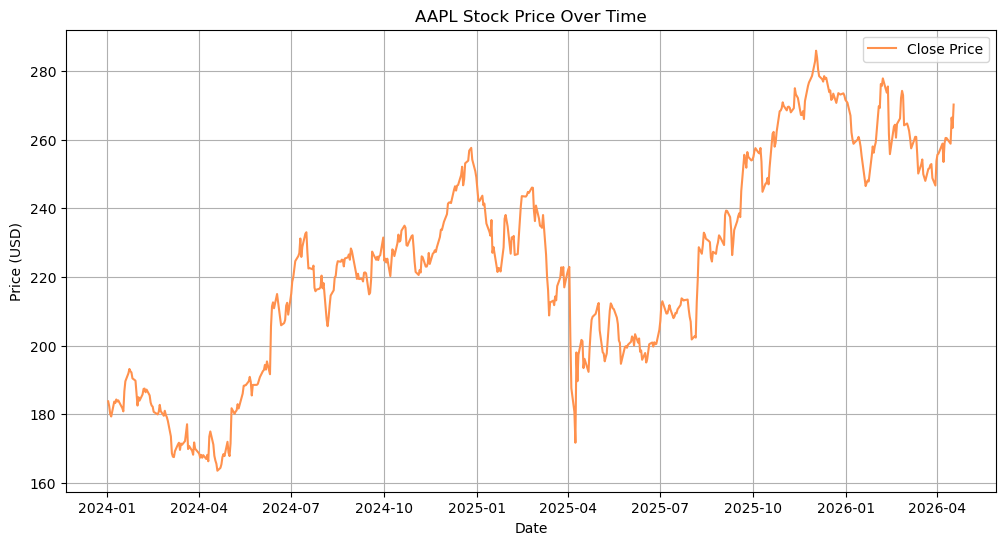

In [2]:
plt.figure(figsize=(12, 6))
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', color='#FF914D')
plt.title('AAPL Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

#Classical Time Series Decompostion

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(stock_data['Close'], model='additive', period=30)

In [5]:
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

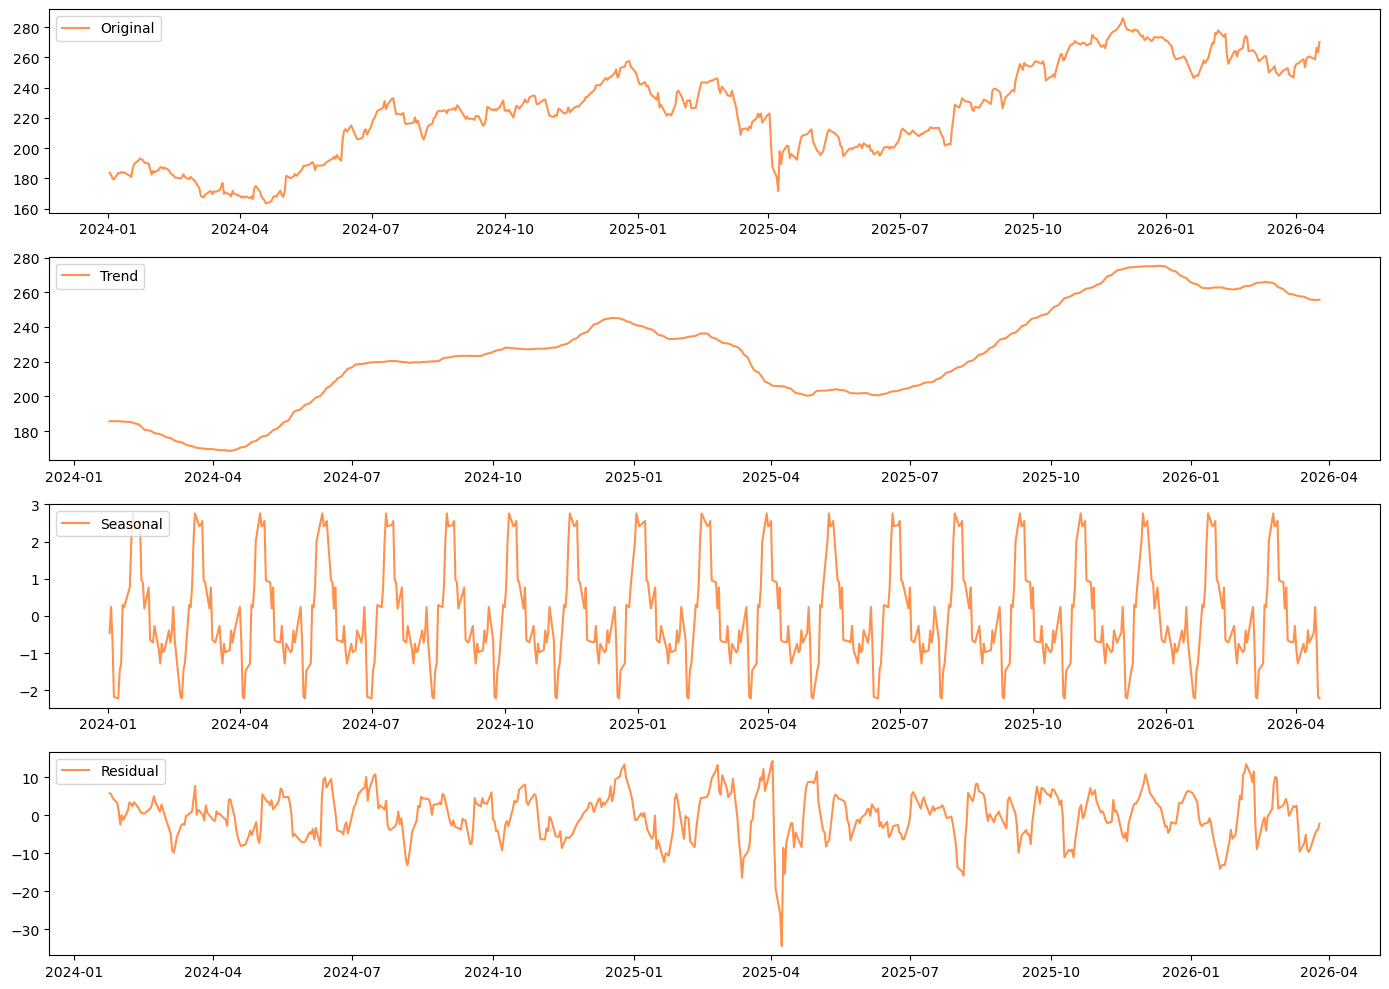

In [6]:
plt.figure(figsize=(14, 10))

# Original Data
plt.subplot(411)
plt.plot(stock_data['Close'], label='Original', color='#FF914D')
plt.legend(loc='upper left')

# Trend Component
plt.subplot(412)
plt.plot(trend_additive, label='Trend', color='#FF914D')
plt.legend(loc='upper left')

# Seasonal Component
plt.subplot(413)
plt.plot(seasonal_additive, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')

# Residual Component
plt.subplot(414)
plt.plot(residual_additive, label='Residual', color='#FF914D')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# STL Decomposition Code (Seasonal-Trend decomposition using LOESS)

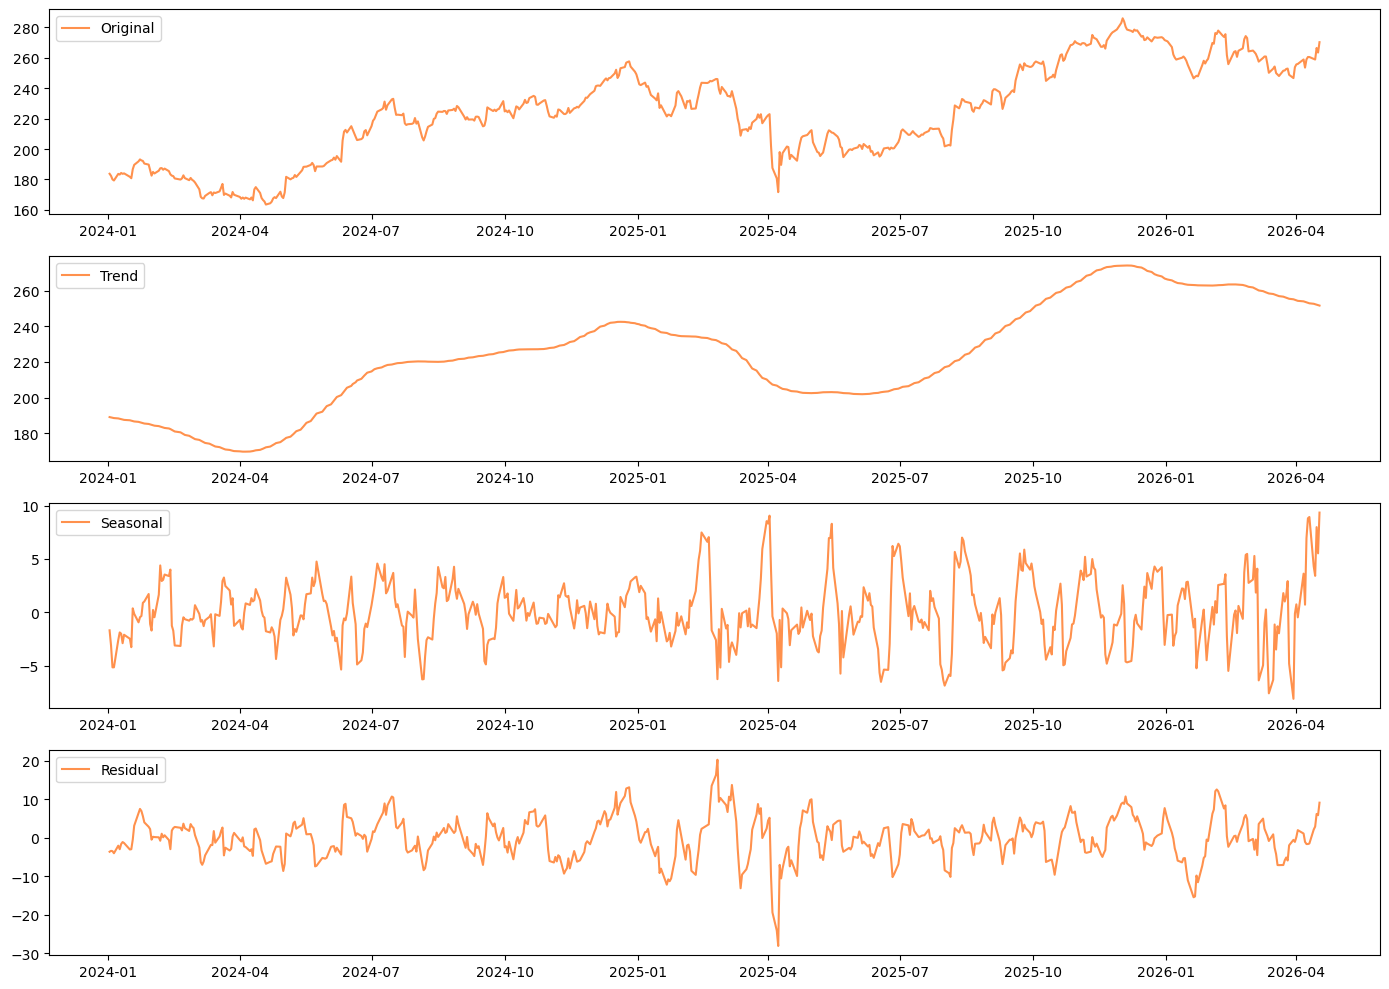

In [7]:
from statsmodels.tsa.seasonal import STL

# Perform STL decomposition
stl = STL(stock_data['Close'], period=30)
result = stl.fit()

# Plot the decomposition components
plt.figure(figsize=(14, 10))

# Observed (Original) Data
plt.subplot(411)
plt.plot(result.observed, label='Original', color='#FF914D')
plt.legend(loc='upper left')

# Trend Component
plt.subplot(412)
plt.plot(result.trend, label='Trend', color='#FF914D')
plt.legend(loc='upper left')

# Seasonal Component
plt.subplot(413)
plt.plot(result.seasonal, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')

# Residual Component
plt.subplot(414)
plt.plot(result.resid, label='Residual', color='#FF914D')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
#Stationarity Test (ADF) Code

In [8]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test
adf_test = adfuller(stock_data['Close'])

print('ADF Test Results:')
print(f'ADF Statistic: {round(adf_test[0], 3)}')
print(f'p-value: {round(adf_test[1], 3)}')
print('Critical Values:')
for key, value in adf_test[4].items():
    print(f'   {key}: {round(value, 3)}')

ADF Test Results:
ADF Statistic: -1.479
p-value: 0.544
Critical Values:
   1%: -3.442
   5%: -2.867
   10%: -2.569


In [9]:
from statsmodels.tsa.stattools import kpss

# Perform the KPSS test
# 'c' for constant (level stationarity), 'ct' for trend stationarity
kpss_test = kpss(stock_data['Close'], regression='ct')

print('KPSS Test Results:')
print(f'KPSS Statistic: {round(kpss_test[0], 2)}')
print(f'p-value: {kpss_test[1]}')
print('Critical Values:')
for key, value in kpss_test[3].items():
    print(f'   {key}: {value}')

KPSS Test Results:
KPSS Statistic: 0.24
p-value: 0.01
Critical Values:
   10%: 0.119
   5%: 0.146
   2.5%: 0.176
   1%: 0.216


C:\Users\urp20\AppData\Local\Temp\ipykernel_8480\2466201946.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(stock_data['Close'], regression='ct')


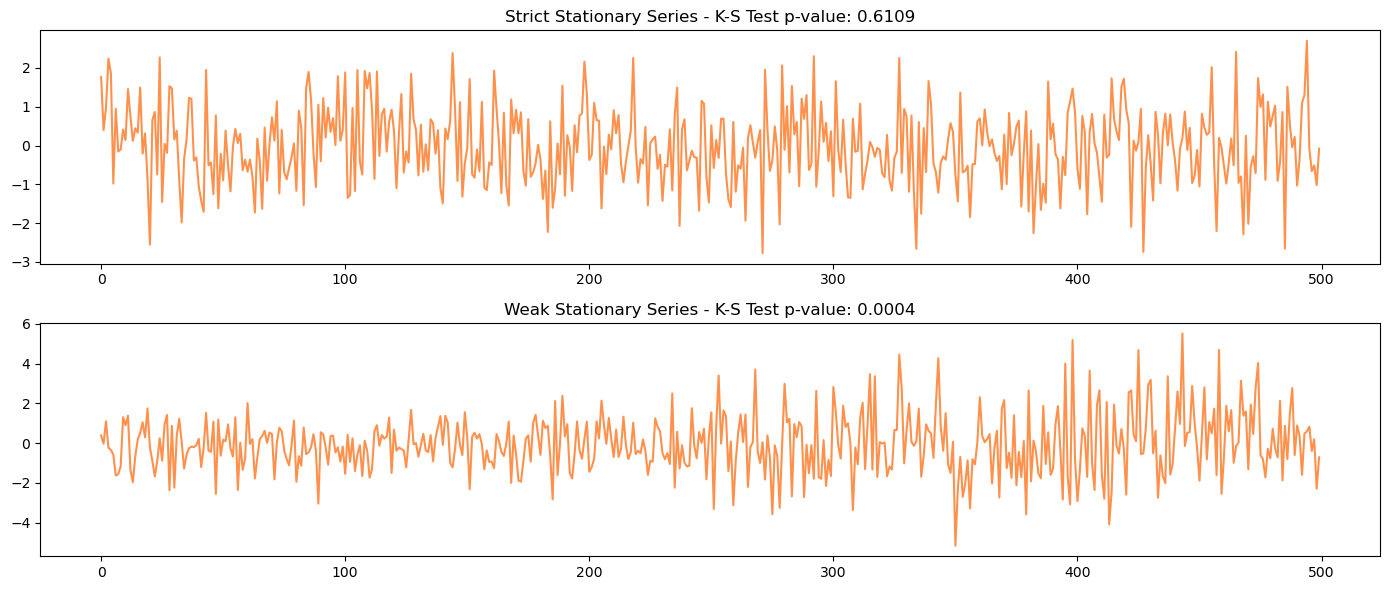

Strict Stationary Series - K-S Test Statistic: 0.068, p-value: 0.6109
Weak Stationary Series - K-S Test Statistic: 0.184, p-value: 0.0004


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Generating synthetic data for demonstration
np.random.seed(0)
n = 500

# Strictly stationary series: normally distributed random noise
strict_stationary_series = np.random.normal(0, 1, n)

# Non-strictly stationary series: changing variance
non_strict_stationary_series = np.concatenate([
    np.random.normal(0, 1, n // 2),
    np.random.normal(0, 2, n // 2)
])

# Function to split the series into two halves and perform the K-S test
def ks_test_stationarity(series):
    split = len(series) // 2
    series_first_half = series[:split]
    series_second_half = series[split:]
    stat, p_value = ks_2samp(series_first_half, series_second_half)
    return stat, p_value

# Perform the K-S test on strictly stationary series
ks_stat_strict, ks_pvalue_strict = ks_test_stationarity(strict_stationary_series)

# Perform the K-S test on non-strictly stationary series
ks_stat_non_strict, ks_pvalue_non_strict = ks_test_stationarity(non_strict_stationary_series)

#plotiing the series
plt.figure(figsize=(14,6))

# Plotting the Strict Stationary Series
plt.subplot(2, 1, 1)
plt.plot(strict_stationary_series, color='#FF914D')
plt.title(f'Strict Stationary Series - K-S Test p-value: {ks_pvalue_strict:.4f}')

# Plotting the Non-Strict Stationary Series
plt.subplot(2, 1, 2)
plt.plot(non_strict_stationary_series, color='#FF914D')
plt.title(f'Weak Stationary Series - K-S Test p-value: {ks_pvalue_non_strict:.4f}')

plt.tight_layout()
plt.show()

# Print Final Results
print(f'Strict Stationary Series - K-S Test Statistic: {ks_stat_strict}, p-value: {ks_pvalue_strict:.4f}')
print(f'Weak Stationary Series - K-S Test Statistic: {ks_stat_non_strict}, p-value: {ks_pvalue_non_strict:.4f}')

In [ ]:
# Making Data Stationary

In [12]:
# Performing ADF and KPSS tests
def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    for key, value in result[4].items():
        print('Critical Value (%s): %.3f' % (key, value))

def kpss_test(series):
    result = kpss(series, regression='c')
    print('KPSS Statistic:', result[0])
    print('p-value:', result[1])
    for key, value in result[3].items():
        print('Critical Value (%s): %.3f' % (key, value))

In [13]:
prices = stock_data['Close']

In [14]:
adf_test(prices)

ADF Statistic: -1.4792142907259525
p-value: 0.5437675334298185
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569


In [15]:
prices

Ticker,AAPL
Date,
2024-01-02,183.731339
2024-01-03,182.355606
2024-01-04,180.039658
2024-01-05,179.317154
2024-01-08,183.652130
...,...
2026-04-13,259.200012
2026-04-14,258.829987
2026-04-15,266.429993


In [16]:
prices_diff = prices.diff()

In [17]:
prices.diff().diff()

Ticker,AAPL
Date,
2024-01-02,NaN
2024-01-03,NaN
2024-01-04,-0.940216
2024-01-05,1.593445
2024-01-08,5.057480
...,...
2026-04-13,-1.270020
2026-04-14,0.909973
2026-04-15,7.970032


In [18]:
prices = prices.dropna()

In [19]:
prices.ndim

2

In [20]:
prices = prices.squeeze()

In [21]:
import numpy as np
from scipy import stats

# Log transformation
# Useful for exponential trends and stabilizing variance
prices_log = np.log(prices)

# Square root transformation
# Often used for count data or to moderate right-skewed data
prices_sqrt = np.sqrt(prices)

# Box-Cox transformation
# A generalized power transformation that finds the optimal 'lambda'
# Note: Box-Cox requires all positive values
prices_boxcox, lam = stats.boxcox(prices[prices > 0])

In [22]:
adf_test(prices_diff.dropna())

ADF Statistic: -22.242224120587814
p-value: 0.0
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569


In [23]:
from scipy import signal

# Using a linear trend
trend = np.polyfit(np.arange(len(prices)), prices.values, 1)
trendline = np.polyval(trend, np.arange(len(prices)))
prices_detrended = prices - trendline




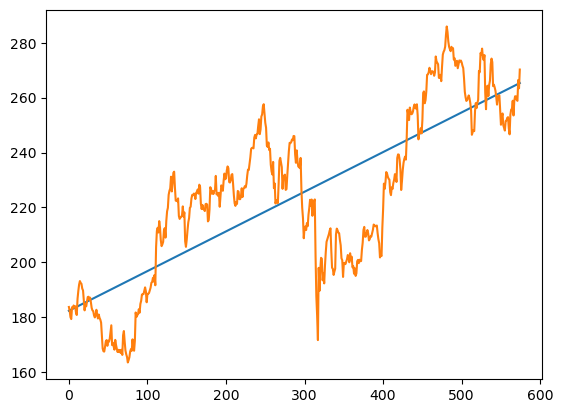

In [24]:
# Plotting the trendline and actual prices
plt.plot(np.arange(len(prices)), trendline)
plt.plot(np.arange(len(prices)), prices)

In [25]:
adf_test(prices_detrended)

ADF Statistic: -2.504342133493156
p-value: 0.11442140827210939
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569


In [26]:
# Using a moving average to remove trend
window = 12  # example window size
prices_ma = prices.rolling(window=window).mean()
prices_detrended = prices - prices_ma
prices_detrended = prices_detrended.dropna()

In [27]:
# Using a moving average to remove trend
window = 12  # example window size
prices_ma = prices.rolling(window=window).mean()
prices_detrended = prices - prices_ma
prices_detrended = prices_detrended.dropna()

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition using moving averages
decomposition = seasonal_decompose(prices, model='additive', period=30)
prices_adjusted = prices / decomposition.seasonal
prices_adjusted = prices_adjusted.dropna()

In [29]:
adf_test(prices_adjusted)

ADF Statistic: -15.902524664673091
p-value: 8.297711215074936e-29
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.570


In [30]:
# Random Walk and White Noise

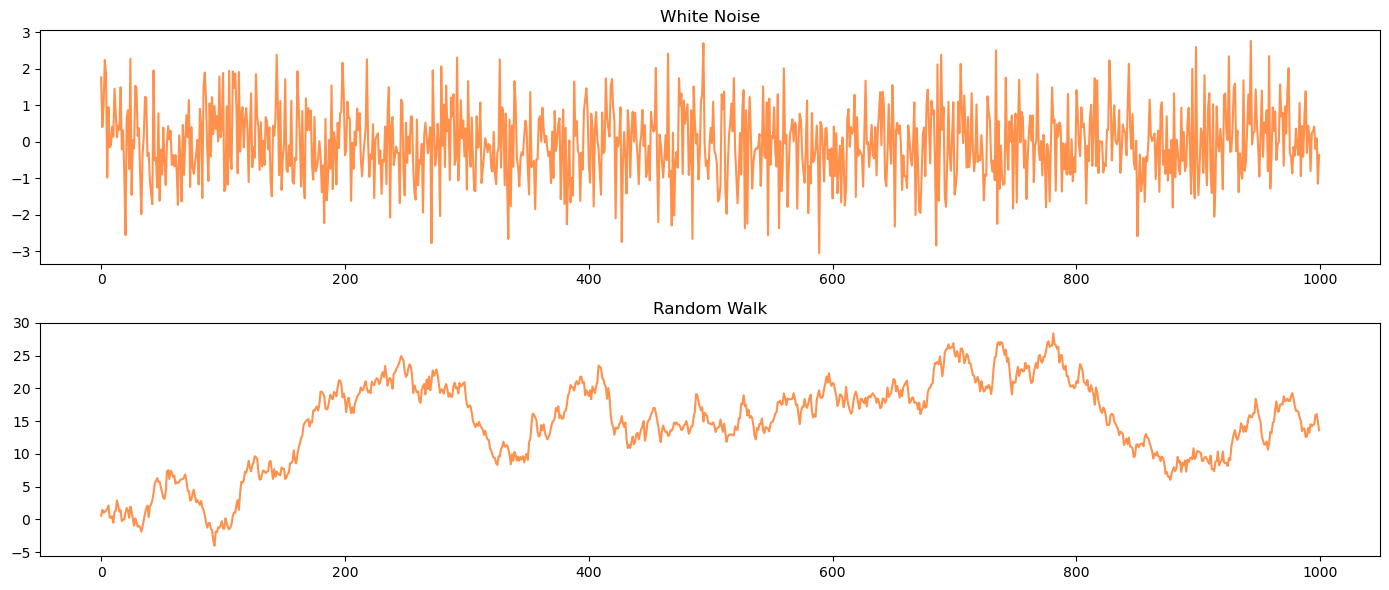


Ljung-Box Test for White Noise:
      lb_stat  lb_pvalue
10  14.025574   0.171828

Ljung-Box Test for Random Walk:
        lb_stat  lb_pvalue
10  8828.660312        0.0


In [31]:
import numpy as np

from statsmodels.stats.diagnostic import acorr_ljungbox

# Generating synthetic data
np.random.seed(0)
n = 1000

# White Noise
white_noise = np.random.normal(0, 1, n)

# Random Walk (Cumulative sum of random shocks)
random_shocks = np.random.normal(0, 1, n)
random_walk = np.cumsum(random_shocks)

# Plotting the series
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(white_noise, color='#FF914D')
plt.title('White Noise')

plt.subplot(2, 1, 2)
plt.plot(random_walk, color='#FF914D')
plt.title('Random Walk')

plt.tight_layout()
plt.show()


# Ljung-Box test for White Noise
print("\nLjung-Box Test for White Noise:")
lb_test_white_noise = acorr_ljungbox(white_noise, lags=[10], return_df=True)
print(lb_test_white_noise)

# Ljung-Box test for Random Walk
print("\nLjung-Box Test for Random Walk:")
lb_test_random_walk = acorr_ljungbox(random_walk, lags=[10], return_df=True)
print(lb_test_random_walk)

In [32]:
#Time Series Forcasting Model



In [33]:
#AR Model

In [34]:
# Making data stationary before model fitting
# .diff() calculates the difference between consecutive periods
stock_data = yf.download('AAPL', start='2023-01-01')
apple_price_stationary = stock_data['Close'].diff().dropna()

# Split the data into training and testing datasets
# Using the last 30 days as the hold-out test set
train_data = apple_price_stationary[:-30]
test_data = apple_price_stationary[-30:]

[*********************100%***********************]  1 of 1 completed


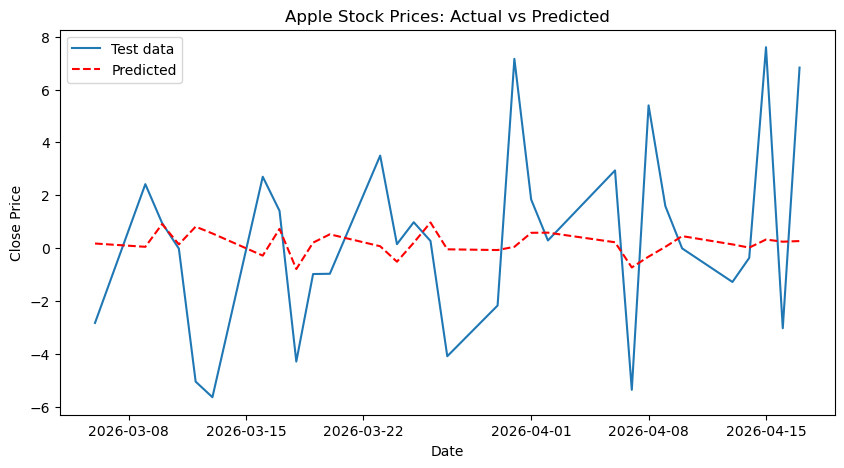

RMSE:  3.52


In [35]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Fit the Autoregressive model (AR) to the training data
# 'lags = 30' means the model uses the past 30 days to predict the next value
model = AutoReg(train_data, lags=30)
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data), 
    end=len(train_data) + len(test_data) - 1, 
    dynamic=False
)


# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluating model using RMSE score
# RMSE tells you, on average, how many dollars the prediction was off by
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE: ', rmse)

In [ ]:
#MA Model

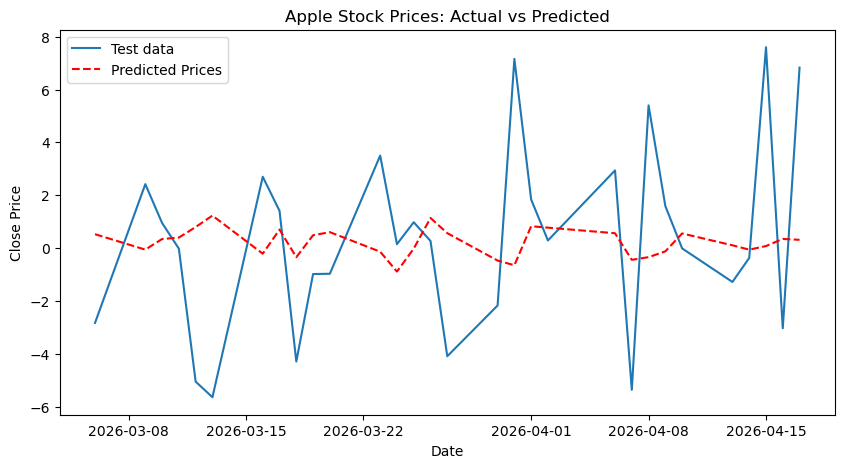

RMSE:  3.7


In [36]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_data, order=(0,0,30))
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print('RMSE: ',rmse)

In [ ]:
# ARMA Model

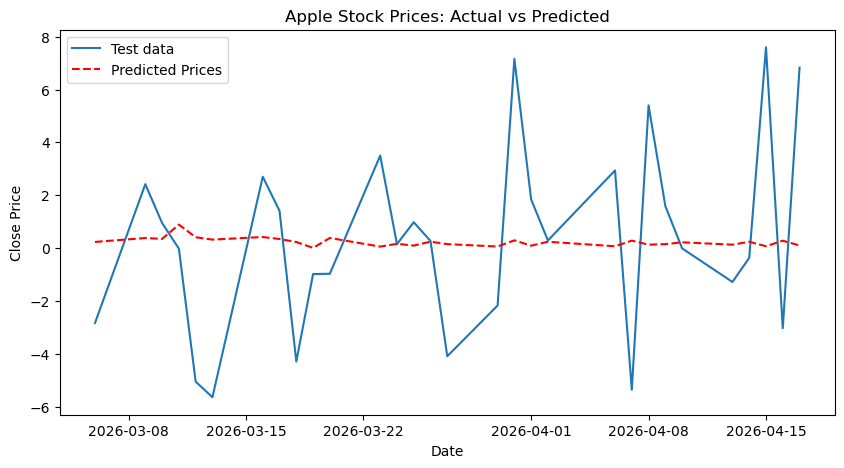

RMSE:  3.56


In [37]:
model = ARIMA(train_data, order=(7,0,7))
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print('RMSE: ',rmse)

In [ ]:
#ARIMA 

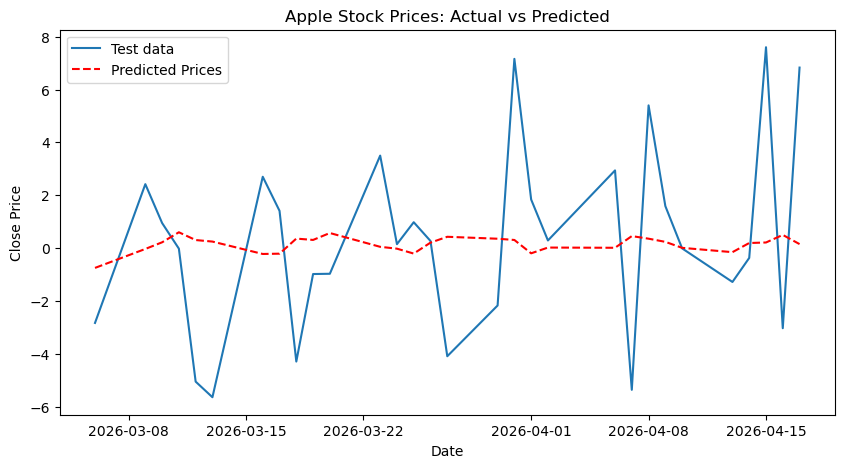

RMSE:  3.59


In [38]:
model = ARIMA(train_data, order=(7,1,7))
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print('RMSE: ',rmse)


In [ ]:
#SARIMA Model

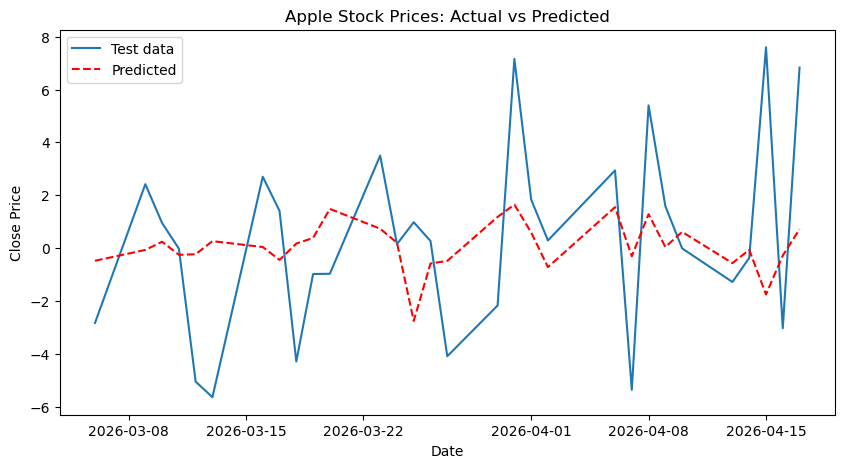

RMSE:  3.5


In [39]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Fit the SARIMA model
p, d, q = 7, 1, 7
P, D, Q, s = 1, 1, 1, 45

# Fit the SARIMA model
model = SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, s))
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print('RMSE: ',rmse)

In [ ]:
# Vector Models

In [41]:
tsla_data = yf.download('TSLA', start='2023-01-01')

stock_data['TSLA_Close'] = tsla_data['Close']
stock_data['AAPL_Close'] = stock_data['Close'].shift()
stock_data.dropna(inplace=True)

from statsmodels.tsa.stattools import grangercausalitytests

# perform Granger-Causality test
grangercausalitytests(stock_data[['AAPL_Close', 'TSLA_Close']].dropna(), maxlag=[14])
print()

[*********************100%***********************]  1 of 1 completed



Granger Causality
number of lags (no zero) 14
ssr based F test:         F=10.6604 , p=0.0000  , df_denom=781, df_num=14
ssr based chi2 test:   chi2=154.7871, p=0.0000  , df=14
likelihood ratio test: chi2=141.6473, p=0.0000  , df=14
parameter F test:         F=10.6604 , p=0.0000  , df_denom=781, df_num=14



In [42]:
stock_data

Price,Close,High,Low,Open,Volume,TSLA_Close,AAPL_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2023-01-04,124.365677,126.629379,123.105880,124.887311,89113600,113.639999,123.096008
2023-01-05,123.046806,125.753403,122.790915,125.123505,80962700,110.339996,124.365677
2023-01-06,127.574226,128.233650,122.918883,124.021209,87754700,113.059998,123.046806
2023-01-09,128.095825,131.304382,127.839934,128.410782,70790800,119.769997,127.574226
2023-01-10,128.666672,129.188306,126.097865,128.204089,63896200,118.849998,128.095825
...,...,...,...,...,...,...,...
2026-04-13,259.200012,260.179993,256.660004,259.730011,36234700,352.420013,260.480011
2026-04-14,258.829987,261.929993,257.190002,259.250000,48370700,364.200012,259.200012


In [43]:
data = stock_data[['AAPL_Close', 'TSLA_Close']].diff().dropna()
train_data, test_data = data[:-14], data[-14:]

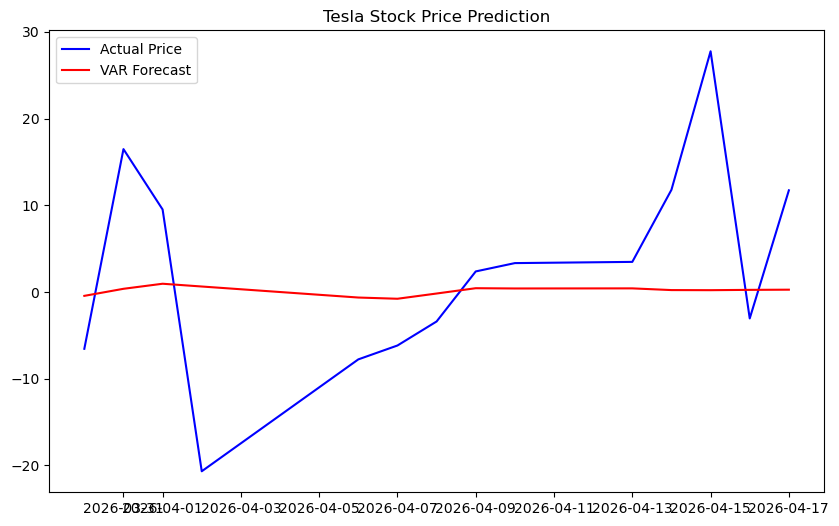

RMSE:  11.86


In [44]:
from statsmodels.tsa.api import VAR, VARMAX
import pandas as pd

# VAR
model = VAR(train_data)
result = model.fit(maxlags=7)
predictions = result.forecast(train_data.values[-result.k_ar:], steps=len(test_data))

predictions = pd.DataFrame(predictions, index=test_data.index, columns=test_data.columns)
plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VAR Forecast', color='red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])), 2)
print('RMSE: ', rmse)

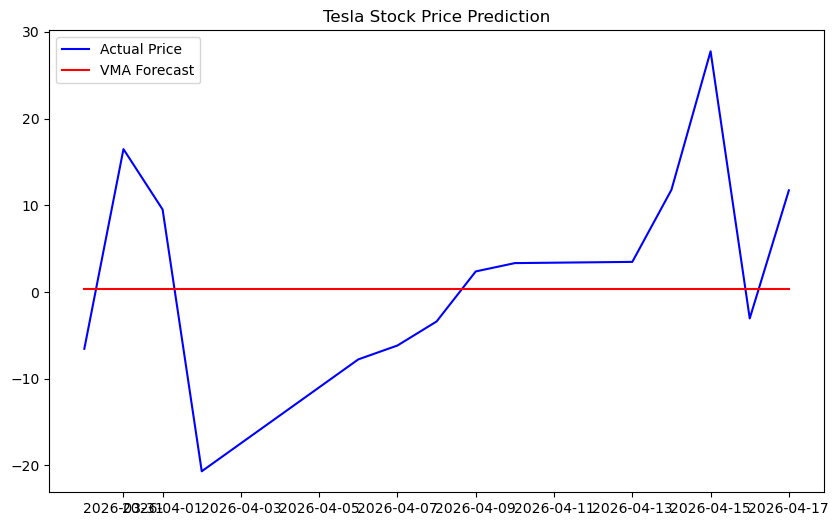

RMSE:  11.96


In [47]:
# VMA
model = VARMAX(train_data, order = (0,14))
result = model.fit()
predictions = result.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False)

plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VMA Forecast', color='red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])), 2)
print('RMSE: ', rmse)

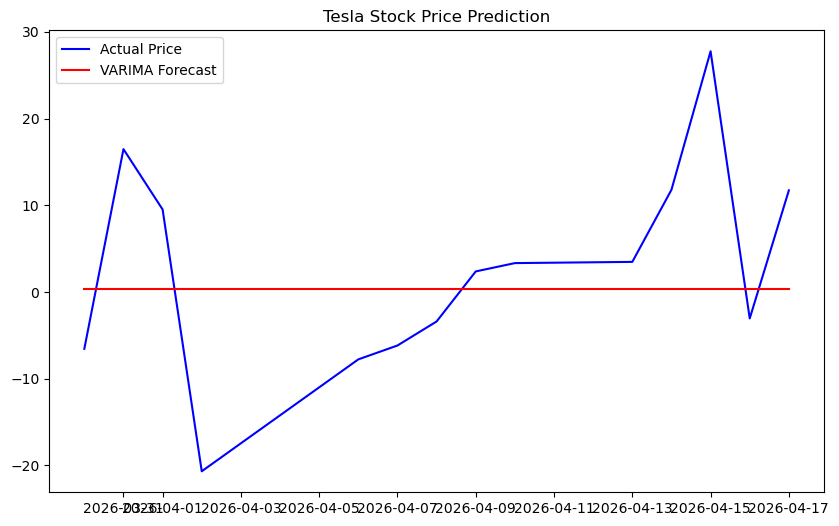

RMSE:  11.96


In [45]:
# VARIMA
model = VARMAX(train_data, order = (14,14))
result = model.fit()
predictions = result.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False)

plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VARIMA Forecast', color='red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])), 2)
print('RMSE: ', rmse)

In [ ]:
# Smoothing Method

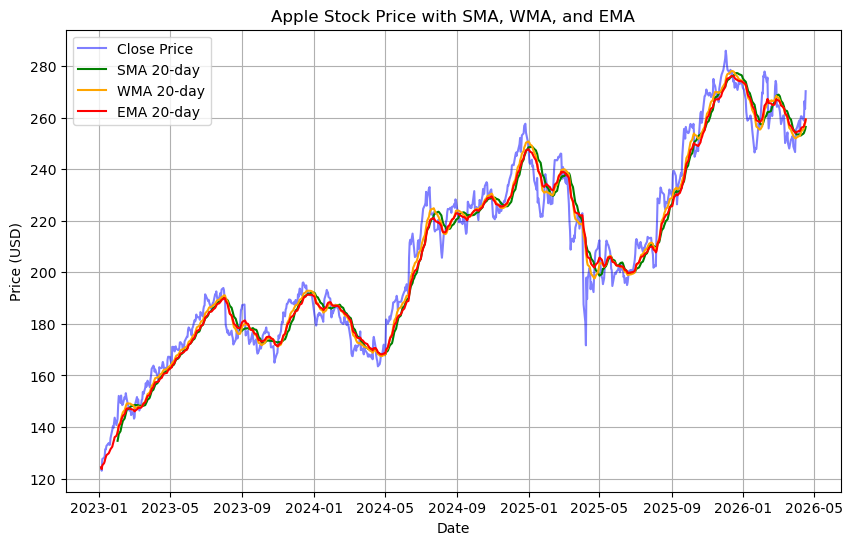

In [48]:
#Moving Average

window_size = 20
stock_data['SMA'] = stock_data['Close'].rolling(window=window_size).mean()

# Calculate Weighted Moving Average (WMA)
weights = np.arange(1, window_size + 1)
stock_data['WMA'] = stock_data['Close'].rolling(window_size).apply(lambda prices: np.dot(prices, weights) / weights.sum(), raw=True)

# Calculate Exponential Moving Average (EMA)
stock_data['EMA'] = stock_data['Close'].ewm(span = window_size).mean()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Close Price', color='blue', alpha=0.5)
plt.plot(stock_data['SMA'], label=f'SMA {window_size}-day', color='green')
plt.plot(stock_data['WMA'], label=f'WMA {window_size}-day', color='orange')
plt.plot(stock_data['EMA'], label=f'EMA {window_size}-day', color='red')

plt.title('Apple Stock Price with SMA, WMA, and EMA')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

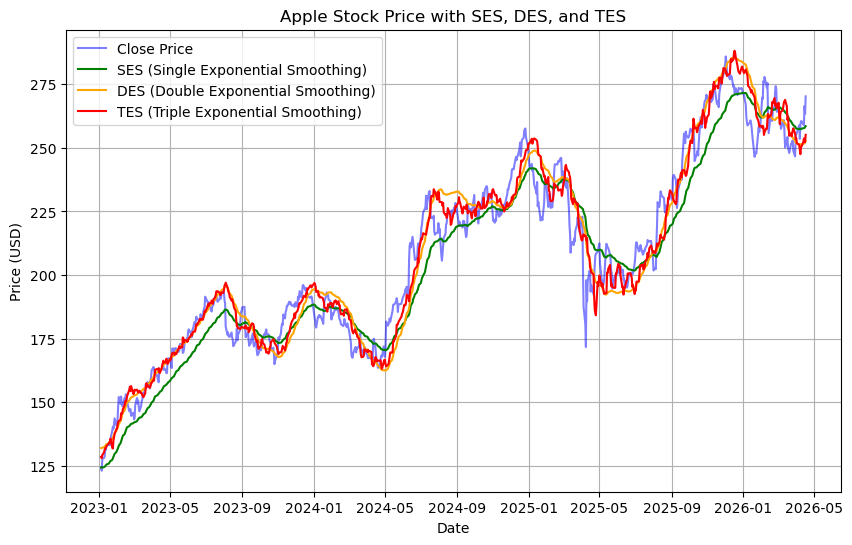

In [52]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

close_prices = stock_data['Close']
ses_model = SimpleExpSmoothing(close_prices).fit(smoothing_level=0.05)
stock_data['SES'] = ses_model.fittedvalues

# Double Exponential Smoothing (DES) - Holt's linear trend model
des_model = ExponentialSmoothing(close_prices, trend='add').fit(smoothing_level=0.05)
stock_data['DES'] = des_model.fittedvalues

# Triple Exponential Smoothing (TES) - Holt-Winters method
tes_model = ExponentialSmoothing(close_prices, trend='add', seasonal='add', seasonal_periods=12).fit(smoothing_level=0.05)
stock_data['TES'] = tes_model.fittedvalues

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Close Price', color='blue', alpha=0.5)
plt.plot(stock_data['SES'], label='SES (Single Exponential Smoothing)', color='green')
plt.plot(stock_data['DES'], label='DES (Double Exponential Smoothing)', color='orange')
plt.plot(stock_data['TES'], label='TES (Triple Exponential Smoothing)', color='red')

plt.title('Apple Stock Price with SES, DES, and TES')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ACF and PACF Plot

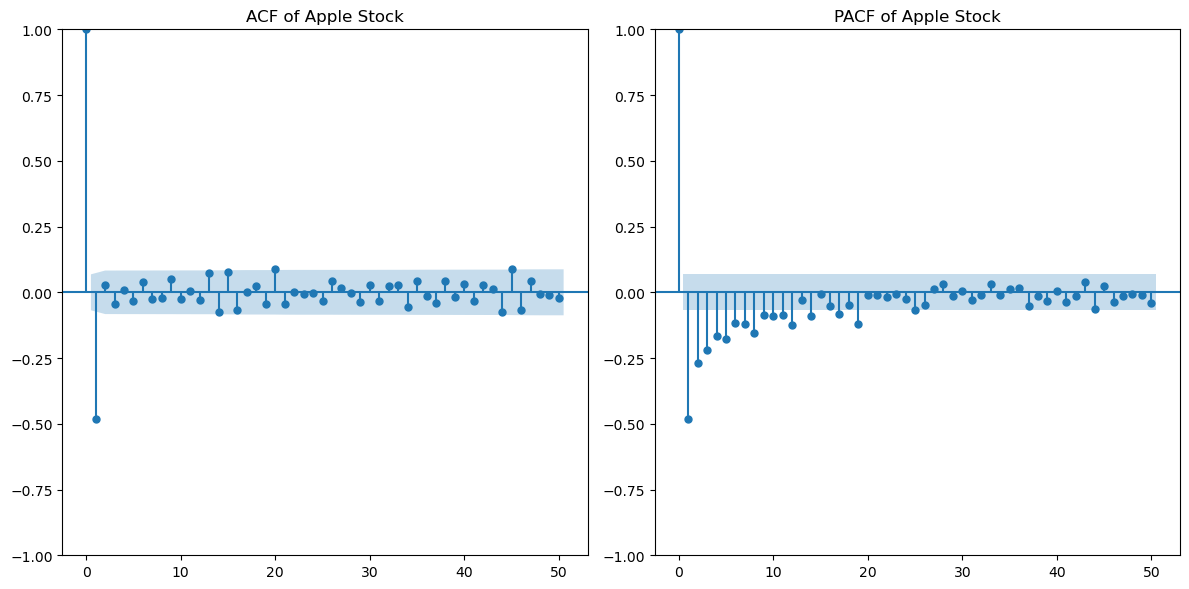

In [53]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12, 6))

# ACF Plot
plt.subplot(1, 2, 1)
plot_acf(stock_data['Close'].diff().diff().dropna(), ax=plt.gca(), lags=50)
plt.title('ACF of Apple Stock')

# PACF Plot
plt.subplot(1, 2, 2)
plot_pacf(stock_data['Close'].diff().diff().dropna(), ax=plt.gca(), lags=50, method='ywm')
plt.title('PACF of Apple Stock')

plt.tight_layout()
plt.show()

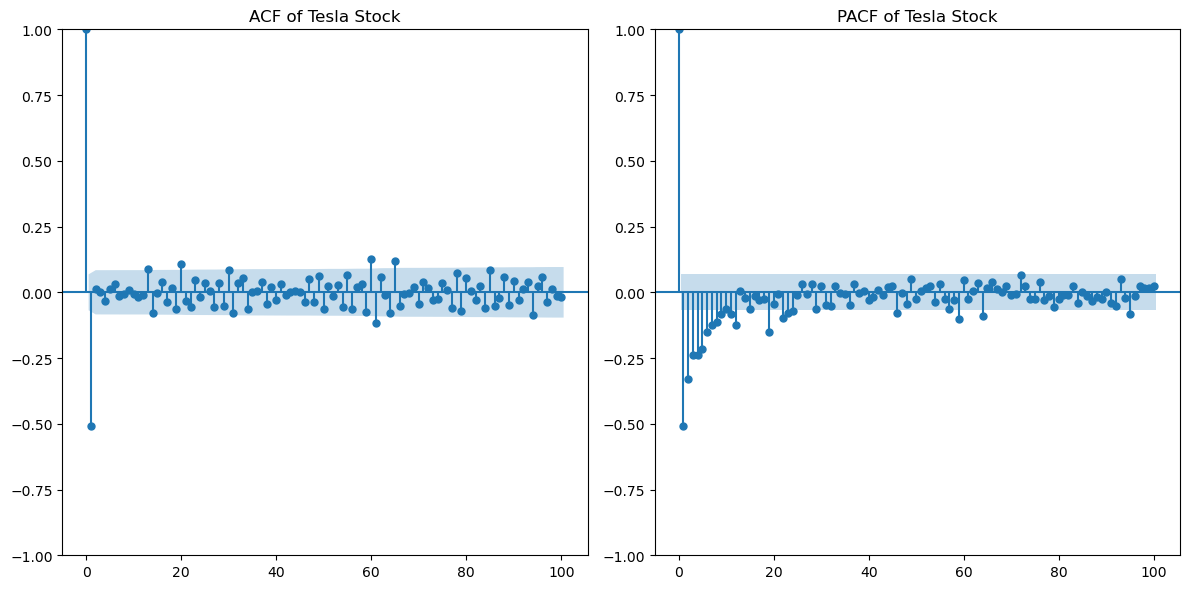

In [55]:
plt.figure(figsize=(12, 6))

# ACF Plot
plt.subplot(1, 2, 1)
plot_acf(tsla_data['Close'].diff().diff().dropna(), ax=plt.gca(), lags=100)
plt.title('ACF of Tesla Stock')

# PACF Plot
plt.subplot(1, 2, 2)
plot_pacf(tsla_data['Close'].diff().diff().dropna(), ax=plt.gca(), lags=100, method='ywm')
plt.title('PACF of Tesla Stock')

plt.tight_layout()
plt.show()

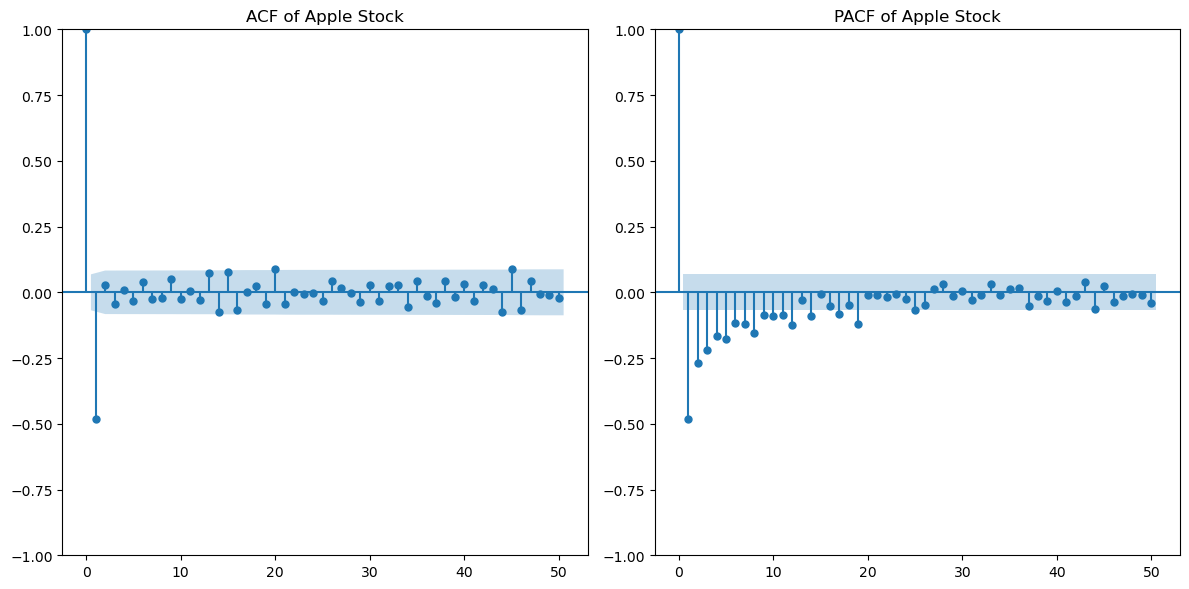

In [56]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12, 6))

# ACF Plot
plt.subplot(1, 2, 1)
plot_acf(stock_data['Close'].diff().diff().dropna(), ax=plt.gca(), lags=50)
plt.title('ACF of Apple Stock')

# PACF Plot
plt.subplot(1, 2, 2)
plot_pacf(stock_data['Close'].diff().diff().dropna(), ax=plt.gca(), lags=50, method='ywm')
plt.title('PACF of Apple Stock')

plt.tight_layout()
plt.show()

In [ ]:
#Model Evaluation Metrics

In [57]:
train_data, test_data = apple_price_stationary[:-30], apple_price_stationary[-30:]

model = AutoReg(train_data, lags=30)
model_fit = model.fit()

predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False
)

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(test_data, predictions)
print(f'Mean Absolute Error (MAE): {mae}')

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(test_data, predictions)
print(f'Mean Squared Error (MSE): {mse}')

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')

# 4. Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((list(test_data) - predictions) / list(test_data))) * 100
print(f'Mean Absolute Percentage Error (MAPE): {mape}%')

# aic and bic
aic = model_fit.aic
bic = model_fit.bic

print(f'Akaike Information Criterion (AIC): {aic}')
print(f'Bayesian Information Criterion (BIC): {bic}')

Mean Absolute Error (MAE): 2.728385778421862
Mean Squared Error (MSE): 12.399321295228418
Root Mean Squared Error (RMSE): 3.521267001411341


UFuncTypeError: ufunc 'subtract' did not contain a loop with signature matching types (dtype('<U4'), dtype('float64')) -> None

In [72]:
model = AutoReg(train_data, lags = 20)
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False)

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(test_data, predictions)
print(f'Mean Absolute Error (MAE): {mae}')

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(test_data, predictions)
print(f'Mean Squared Error (MSE): {mse}')

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')

# 4. Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((list(test_data) - predictions) / list(test_data))) * 100
print(f'Mean Absolute Percentage Error (MAPE): {mape}%')

# aic and bic
aic = model_fit.aic
bic = model_fit.bic

print(f'Akaike Information Criterion (AIC): {aic}')
print(f'Bayesian Information Criterion (BIC): {bic}')

Mean Absolute Error (MAE): 2.6644833301308566
Mean Squared Error (MSE): 12.141029515827078
Root Mean Squared Error (RMSE): 3.484398013405914


UFuncTypeError: ufunc 'subtract' did not contain a loop with signature matching types (dtype('<U4'), dtype('float64')) -> None

In [ ]:
# Data Preprocessing

In [ ]:
#Handling Missing values

In [73]:
data = {
    'Date': ['2024-01-01', '2024-01-02', '2024-01-04', '2024-01-07', '2024-01-08', '2024-01-09', '2024-01-10', '2024-01-12'],
    'Price': [100, 101, 103, 106, 107, 108, 109, 111]
}

# Create a DataFrame
data = pd.DataFrame(data)
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

data

,Price
Date,
2024-01-01,100
2024-01-02,101
2024-01-04,103
2024-01-07,106
2024-01-08,107
2024-01-09,108
2024-01-10,109
2024-01-12,111


In [74]:
# Create a complete date range
complete_index = pd.date_range(start='2024-01-01', end='2024-01-12', freq='D')

# Reindex the DataFrame
data = data.reindex(complete_index)

print("Reindexed DataFrame with Missing Dates:\n", data)

Reindexed DataFrame with Missing Dates:
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03    NaN
2024-01-04  103.0
2024-01-05    NaN
2024-01-06    NaN
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11    NaN
2024-01-12  111.0


In [ ]:
# 1 Imputation

In [76]:
# Mean Imputation
mean_value = data.mean()
data_mean_imputed = data.fillna(mean_value)

# Median Imputation
median_value = data.median()
data_median_imputed = data.fillna(median_value)

# Mode Imputation
mode_value = data.mode()
data_mode_imputed = data.fillna(mode_value.values[0][0])

# Forward Fill (Carries the last known value forward)
data_ffill = data.ffill()

# Backward Fill (Uses the next known value)
data_bfill = data.bfill()

print("Original Data:\n", data)
print('----------\nMean:', mean_value.values[0])
print("----------\nMean Imputation:\n", data_mean_imputed)

print('-----------\nMedian:', median_value.values[0])
print("-----------\nMedian Imputation:\n", data_median_imputed)

print('-----------\nMode:', mode_value.values[0][0])
print("-----------\nMode Imputation:\n", data_mode_imputed)

print("-----------\nForward Fill:\n", data_ffill)
print("-----------\nBackward Fill:\n", data_bfill)

Original Data:
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03    NaN
2024-01-04  103.0
2024-01-05    NaN
2024-01-06    NaN
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11    NaN
2024-01-12  111.0
----------
Mean: 105.625
----------
Mean Imputation:
               Price
2024-01-01  100.000
2024-01-02  101.000
2024-01-03  105.625
2024-01-04  103.000
2024-01-05  105.625
2024-01-06  105.625
2024-01-07  106.000
2024-01-08  107.000
2024-01-09  108.000
2024-01-10  109.000
2024-01-11  105.625
2024-01-12  111.000
-----------
Median: 106.5
-----------
Median Imputation:
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03  106.5
2024-01-04  103.0
2024-01-05  106.5
2024-01-06  106.5
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11  106.5
2024-01-12  111.0
-----------
Mode: 100.0
-----------
Mode Imputation:
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03  100.0
2024-01-04  103.0


In [ ]:
# 2 Interpolation

In [77]:
# Linear Interpolation
data_linear_interp = data.interpolate(method='linear')

# Polynomial Interpolation (degree 2)
data_poly_interp = data.interpolate(method='polynomial', order=2)

# Spline Interpolation (order 2)
data_spline_interp = data.interpolate(method='spline', order=2)

print("\nLinear Interpolation:\n", data_linear_interp)
print("\nPolynomial Interpolation (degree 2):\n", data_poly_interp)
print("\nSpline Interpolation (order 2):\n", data_spline_interp)


Linear Interpolation:
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03  102.0
2024-01-04  103.0
2024-01-05  104.0
2024-01-06  105.0
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11  110.0
2024-01-12  111.0

Polynomial Interpolation (degree 2):
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03  102.0
2024-01-04  103.0
2024-01-05  104.0
2024-01-06  105.0
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11  110.0
2024-01-12  111.0

Spline Interpolation (order 2):
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03  102.0
2024-01-04  103.0
2024-01-05  104.0
2024-01-06  105.0
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11  110.0
2024-01-12  111.0


In [ ]:
#3. Predictive Modelling

In [78]:
data['Sales'] = [700, 900, 1000, 2000, 1500, 3000, 2300, 4000, 5900, 6000, 65000, 7000]
data

,Price,Sales
2024-01-01,100.0,700
2024-01-02,101.0,900
2024-01-03,NaN,1000
2024-01-04,103.0,2000
2024-01-05,NaN,1500
2024-01-06,NaN,3000
2024-01-07,106.0,2300
2024-01-08,107.0,4000
2024-01-09,108.0,5900
2024-01-10,109.0,6000


In [79]:
from sklearn.linear_model import LinearRegression

known_data = data.dropna(subset=['Price'])
missing_data = data[data['Price'].isna()]

# Train a model on known data
model = LinearRegression()
model.fit(known_data[['Sales']], known_data['Price'])

# Predict missing values
predicted_values = model.predict(missing_data[['Sales']])
data.loc[data['Price'].isna(), 'Price'] = predicted_values

print("\nData with Predicted Values:\n", data)


Data with Predicted Values:
                  Price  Sales
2024-01-01  100.000000    700
2024-01-02  101.000000    900
2024-01-03  101.675094   1000
2024-01-04  103.000000   2000
2024-01-05  102.434691   1500
2024-01-06  104.713483   3000
2024-01-07  106.000000   2300
2024-01-08  107.000000   4000
2024-01-09  108.000000   5900
2024-01-10  109.000000   6000
2024-01-11  198.903558  65000
2024-01-12  111.000000   7000


In [ ]:
#Resampling

In [ ]:
    #1. Downsampling

In [80]:
monthly_data = stock_data['Close'].resample('M').mean()
print("\nMonthly Downsampled Data:\n", monthly_data)


Monthly Downsampled Data:
 Ticker            AAPL
Date                  
2023-01-31  134.190738
2023-02-28  148.728723
2023-03-31  152.751852
2023-04-30  162.688897
2023-05-31  170.297707
2023-06-30  181.902980
2023-07-31  189.926161
2023-08-31  178.900718
2023-09-30  174.952126
2023-10-31  172.645296
2023-11-30  183.890573
2023-12-31  192.310683
2024-01-31  185.794160
2024-02-29  183.037861
2024-03-31  171.138988
2024-04-30  168.074917
2024-05-31  184.779427
2024-06-30  204.680165
2024-07-31  222.874919
2024-08-31  220.113757
2024-09-30  222.297746
2024-10-31  228.554733
2024-11-30  226.511670
2024-12-31  247.968283
2025-01-31  233.312480
2025-02-28  237.412227
2025-03-31  221.736434
2025-04-30  200.310774
2025-05-31  203.240835
2025-06-30  200.048235
2025-07-31  210.639913
2025-08-31  224.151281
2025-09-30  242.024886
2025-10-31  257.803836
2025-11-30  271.333742
2025-12-31  276.048058
2026-01-31  257.408636
2026-02-28  269.111013
2026-03-31  254.906363
2026-04-30  260.155832


In [ ]:
#2. Upsampling

In [81]:
hourly_data = stock_data['Close'].resample('H').interpolate(method='linear')
print("\nHourly Upsampled Data:\n", hourly_data)


Hourly Upsampled Data:
 Ticker                     AAPL
Date                           
2023-01-04 00:00:00  124.365677
2023-01-04 01:00:00  124.310724
2023-01-04 02:00:00  124.255771
2023-01-04 03:00:00  124.200818
2023-01-04 04:00:00  124.145865
...                         ...
2026-04-16 20:00:00  269.091675
2026-04-16 21:00:00  269.376259
2026-04-16 22:00:00  269.660843
2026-04-16 23:00:00  269.945427
2026-04-17 00:00:00  270.230011

[28777 rows x 1 columns]
